In [1]:
import pandas as pd

# Load Dataset
df = pd.read_csv(r"C:\Users\kesha\Downloads\Groceries_dataset.csv")

# Display first 10 rows
print(df.head(10))

# Display columns
print("Columns:", df.columns)

# Number of rows and columns
print("Dataset Shape:", df.shape)

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk
5           4941  14-02-2015        rolls/buns
6           4501  08-05-2015  other vegetables
7           3803  23-12-2015        pot plants
8           2762  20-03-2015        whole milk
9           4119  12-02-2015    tropical fruit
Columns: Index(['Member_number', 'Date', 'itemDescription'], dtype='str')
Dataset Shape: (38765, 3)


In [2]:
print(df.shape[0])

38765


In [3]:
transactions = (
    df.groupby(['Member_number', 'Date'])['itemDescription']
      .apply(list)
      .tolist()
)

print(transactions[:5])

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]


In [6]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

basket = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(basket, columns=te.columns_)

print(basket.head())

print("Basket Matrix Shape:", basket.shape)

   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisky  white bread  \
0  ...   False 

In [7]:
from mlxtend.frequent_patterns import apriori

supports = [0.01, 0.02]

for support in supports:

    print("="*60)
    print("Support:", support)

    frequent_itemsets = apriori(
        basket,
        min_support=support,
        use_colnames=True
    )

    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

    print(frequent_itemsets.head(10))

    print("Total Frequent Itemsets:",
          len(frequent_itemsets))

    print("Largest Itemset Length:",
          frequent_itemsets['length'].max())

Support: 0.01
    support                    itemsets  length
0  0.021386       frozenset({UHT-milk})       1
1  0.033950           frozenset({beef})       1
2  0.021787        frozenset({berries})       1
3  0.016574      frozenset({beverages})       1
4  0.045312   frozenset({bottled beer})       1
5  0.060683  frozenset({bottled water})       1
6  0.037626    frozenset({brown bread})       1
7  0.035220         frozenset({butter})       1
8  0.017577    frozenset({butter milk})       1
9  0.014369          frozenset({candy})       1
Total Frequent Itemsets: 69
Largest Itemset Length: 2
Support: 0.02
    support                    itemsets  length
0  0.021386       frozenset({UHT-milk})       1
1  0.033950           frozenset({beef})       1
2  0.021787        frozenset({berries})       1
3  0.045312   frozenset({bottled beer})       1
4  0.060683  frozenset({bottled water})       1
5  0.037626    frozenset({brown bread})       1
6  0.035220         frozenset({butter})       1
7  0.0

In [8]:
print(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

     support                       itemsets  length
36  0.157923        frozenset({whole milk})       1
24  0.122101  frozenset({other vegetables})       1
28  0.110005        frozenset({rolls/buns})       1
32  0.097106              frozenset({soda})       1
37  0.085879            frozenset({yogurt})       1
29  0.069572   frozenset({root vegetables})       1
33  0.067767    frozenset({tropical fruit})       1
4   0.060683     frozenset({bottled water})       1
30  0.060349           frozenset({sausage})       1
10  0.053131      frozenset({citrus fruit})       1


In [9]:
frequent_itemsets['length'].max()

1

In [10]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.10
)

print(
rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']]
)

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [11]:
top_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(10)

print(top_rules)

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


In [12]:
import matplotlib.pyplot as plt


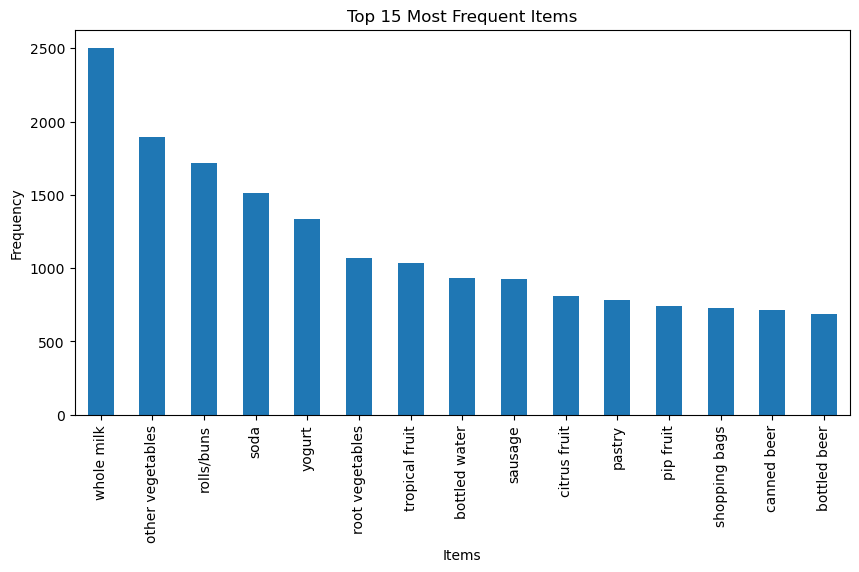

In [14]:
import matplotlib.pyplot as plt

top15 = df['itemDescription'].value_counts().head(15)

plt.figure(figsize=(10,5))

top15.plot(kind='bar')

plt.title("Top 15 Most Frequent Items")

plt.xlabel("Items")

plt.ylabel("Frequency")

plt.show()

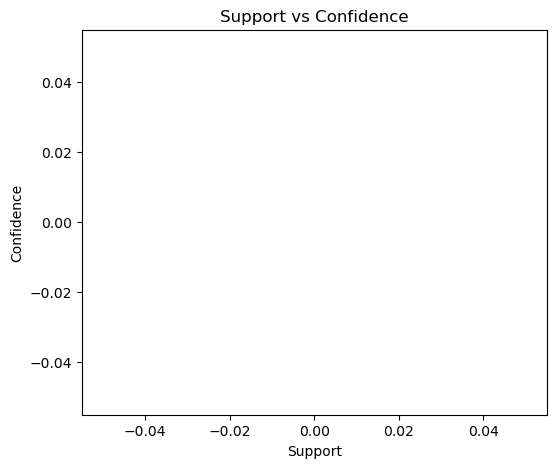

In [15]:
plt.figure(figsize=(6,5))

plt.scatter(
    rules['support'],
    rules['confidence']
)

plt.xlabel("Support")

plt.ylabel("Confidence")

plt.title("Support vs Confidence")

plt.show()

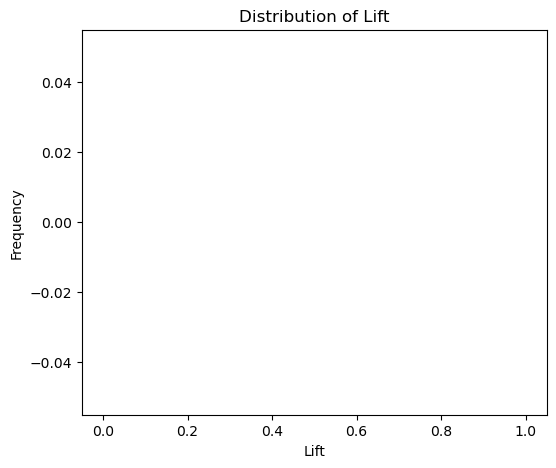

In [16]:
plt.figure(figsize=(6,5))

plt.hist(rules['lift'], bins=20)

plt.xlabel("Lift")

plt.ylabel("Frequency")

plt.title("Distribution of Lift")

plt.show()

In [17]:
pivot = pd.pivot_table(
    df,
    index='itemDescription',
    values='Member_number',
    aggfunc='count'
)

pivot.columns=['Transaction Count']

print(pivot)

                       Transaction Count
itemDescription                         
Instant food products                 60
UHT-milk                             323
abrasive cleaner                      22
artif. sweetener                      29
baby cosmetics                         3
...                                  ...
white bread                          362
white wine                           176
whole milk                          2502
yogurt                              1334
zwieback                              60

[167 rows x 1 columns]


In [18]:
pivot = pd.pivot_table(
    df,
    index='itemDescription',
    values='Member_number',
    aggfunc='count'
)

pivot.columns=['Transaction Count']

print(pivot)

                       Transaction Count
itemDescription                         
Instant food products                 60
UHT-milk                             323
abrasive cleaner                      22
artif. sweetener                      29
baby cosmetics                         3
...                                  ...
white bread                          362
white wine                           176
whole milk                          2502
yogurt                              1334
zwieback                              60

[167 rows x 1 columns]


In [19]:
plt.figure(figsize=(10,5))

top10.plot(kind='bar')

plt.title("Top 10 Most Frequently Purchased Items")

plt.xlabel("Items")

plt.ylabel("Transaction Count")

plt.show()

NameError: name 'top10' is not defined

<Figure size 1000x500 with 0 Axes>